## Epic 2: Visualizing and Analysing the Data
This section explores the raw, unprocessed dataset to understand distributions, 
detect class imbalance, spot outliers, and identify relationships between features 
before any cleaning is performed.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (8, 5)

In [2]:
app_df = pd.read_csv(r"C:\Users\krish\Downloads\credit_card_approval_dataset - Copy\application_record.csv")
cred_df = pd.read_csv(r"C:\Users\krish\Downloads\credit_card_approval_dataset - Copy\credit_record.csv")

app_df.head()

,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS
0,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0
1,5008805,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0
2,5008806,M,Y,Y,0,112500.0,Working,Secondary / secondary special,Married,House / apartment,-21474,-1134,1,0,0,0,Security staff,2.0
3,5008808,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0
4,5008809,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0


In [3]:
cred_df.head()

,ID,MONTHS_BALANCE,STATUS
0,5001711,0,X
1,5001711,-1,0
2,5001711,-2,0
3,5001711,-3,0
4,5001712,0,C


### About the data
Two raw files are used in this project:
- `application_record.csv` — 438,557 rows, 18 columns of applicant demographic and 
  financial attributes (gender, income, family status, employment, etc.)
- `credit_record.csv` — 1,048,575 rows, monthly credit history records used later 
  (Epic 3) to derive the approval/rejection target label.

Epic 2 focuses mainly on `application_record.csv`, since that's where the 
predictive features live.

## Univariate Analysis

### 1.1 Gender distribution

In [13]:
# Table
table = app_df['CODE_GENDER'].value_counts().reset_index()
table.columns = ['CODE_GENDER', 'Count']
table['Percentage'] = round((table['Count'] / table['Count'].sum()) * 100, 2)
table

,CODE_GENDER,Count,Percentage
0,F,294440,67.14
1,M,144117,32.86


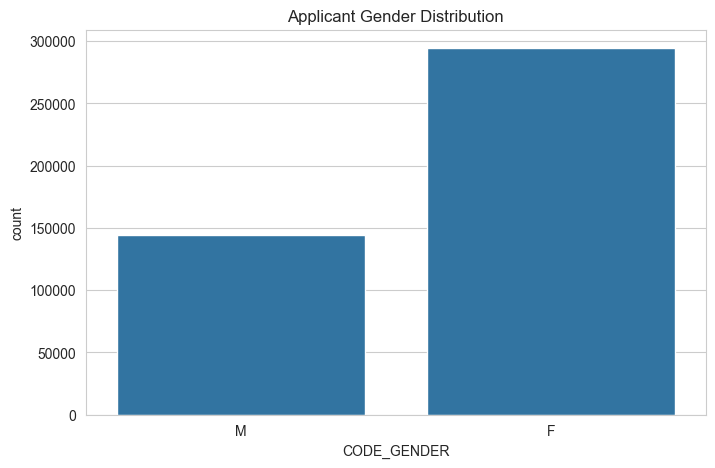

In [4]:
sns.countplot(x='CODE_GENDER', data=app_df)
plt.title('Applicant Gender Distribution')
plt.show()

### Finding:
The dataset is imbalanced by gender — 294,440 female applicants (67%) 
vs 144,117 male applicants (33%), roughly a 2:1 ratio.

### 1.2 Income distribution

In [14]:
# Table
table = app_df['AMT_INCOME_TOTAL'].describe().to_frame().round(2)
table

,AMT_INCOME_TOTAL
count,438557.00
mean,187524.29
std,110086.85
min,26100.00
25%,121500.00
50%,160780.50
75%,225000.00
max,6750000.00


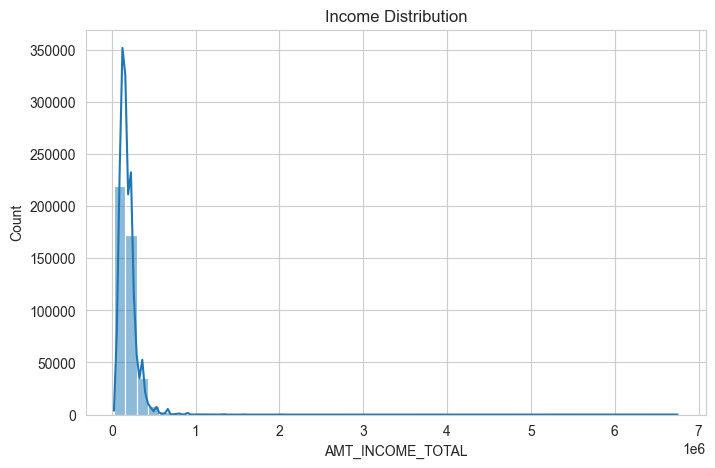

In [5]:
sns.histplot(app_df['AMT_INCOME_TOTAL'], bins=50, kde=True)
plt.title('Income Distribution') # each value at x axis represents a million
plt.show()

### Finding: 
Income is heavily right-skewed. Median income is ~160,780, but the 
mean is pulled up to ~187,524 by a long tail — the maximum recorded income is 
6,750,000, a clear outlier worth flagging for Epic 3.

### 1.3 Number of children

In [12]:
# Table
table = app_df['CNT_CHILDREN'].value_counts().reset_index()
table.columns = ['CNT_CHILDREN', 'Count']
table['Percentage'] = round((table['Count'] / table['Count'].sum()) * 100, 2)
table

,CNT_CHILDREN,Count,Percentage
0,0,304071,69.33
1,1,88527,20.19
2,2,39884,9.09
3,3,5430,1.24
4,4,486,0.11
5,5,133,0.03
6,7,9,0.00
7,9,5,0.00
8,12,4,0.00
9,6,4,0.00


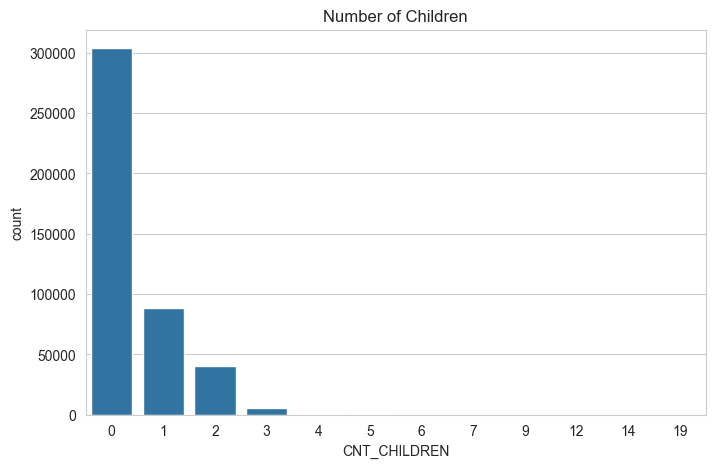

In [6]:
sns.countplot(x='CNT_CHILDREN', data=app_df)
plt.title('Number of Children')
plt.show()

### Finding: 
Most applicants (over 70%) have zero children. A small number of 
extreme outliers report up to 19 children, which is almost certainly a data 
entry anomaly rather than a real value.

### 1.4 Income type

In [11]:
# Table
table = app_df['NAME_INCOME_TYPE'].value_counts().reset_index()
table.columns = ['NAME_INCOME_TYPE', 'Count']
table['Percentage'] = round((table['Count'] / table['Count'].sum()) * 100, 2)
table

,NAME_INCOME_TYPE,Count,Percentage
0,Working,226104,51.56
1,Commercial associate,100757,22.97
2,Pensioner,75493,17.21
3,State servant,36186,8.25
4,Student,17,0.00


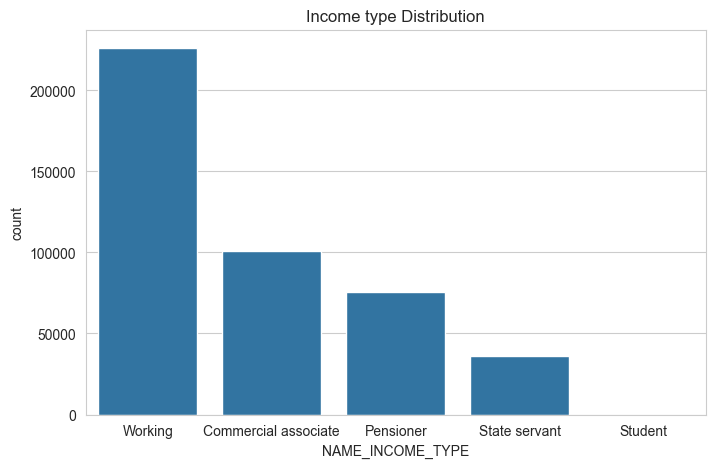

In [7]:
sns.countplot(x='NAME_INCOME_TYPE', data=app_df)
plt.title('Income type Distribution')
plt.show()

### Findings:
  Income type: "Working" dominates at 226,104 applicants (51.6%), followed by 
  Commercial associate (100,757) and Pensioner (75,493). "Student" is nearly 
  absent (17 rows) — a class this rare may need to be merged or dropped later.

## 1.5 education type

In [15]:
# Table
table = app_df['NAME_EDUCATION_TYPE'].value_counts().reset_index()
table.columns = ['NAME_EDUCATION_TYPE', 'Count']
table['Percentage'] = round((table['Count'] / table['Count'].sum()) * 100, 2)
table

,NAME_EDUCATION_TYPE,Count,Percentage
0,Secondary / secondary special,301821,68.82
1,Higher education,117522,26.80
2,Incomplete higher,14851,3.39
3,Lower secondary,4051,0.92
4,Academic degree,312,0.07


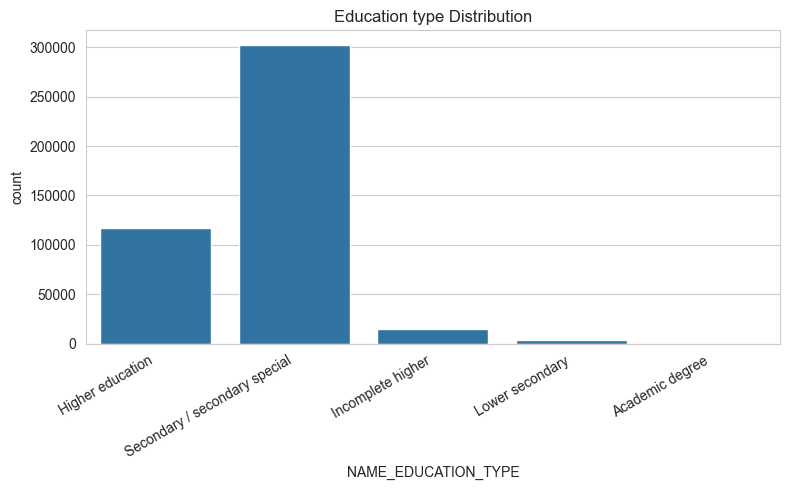

In [10]:
sns.countplot(x='NAME_EDUCATION_TYPE', data=app_df)
plt.title('Education type Distribution')
plt.xticks(rotation=30, ha='right')  # Rotate labels
plt.tight_layout() 
plt.show()

### Findings:
Education: 301,821 applicants (68.8%) have only secondary education; higher education holders are a minority (117,522).

### 1.6 Family status

In [18]:
# Table
table = app_df['NAME_FAMILY_STATUS'].value_counts().reset_index()
table.columns = ['NAME_FAMILY_STATUS', 'Count']
table['Percentage'] = round((table['Count'] / table['Count'].sum()) * 100, 2)
table

,NAME_FAMILY_STATUS,Count,Percentage
0,Married,299828,68.37
1,Single / not married,55271,12.60
2,Civil marriage,36532,8.33
3,Separated,27251,6.21
4,Widow,19675,4.49


In [ ]:
sns.countplot(x='NAME_FAMILY_STATUS', data=app_df)
plt.title('Family status distribution')
plt.show()

### Findings:
Family status: Married applicants dominate (299,828, ~68%) followed by single/unmarried with 12%

## 1.7 Housing type

In [23]:
# Table
table = app_df['NAME_HOUSING_TYPE'].value_counts().reset_index()
table.columns = ['NAME_HOUSING_TYPE', 'Count']
table['Percentage'] = round((table['Count'] / table['Count'].sum()) * 100, 2)
table

,NAME_HOUSING_TYPE,Count,Percentage
0,House / apartment,393831,89.80
1,With parents,19077,4.35
2,Municipal apartment,14214,3.24
3,Rented apartment,5974,1.36
4,Office apartment,3922,0.89
5,Co-op apartment,1539,0.35


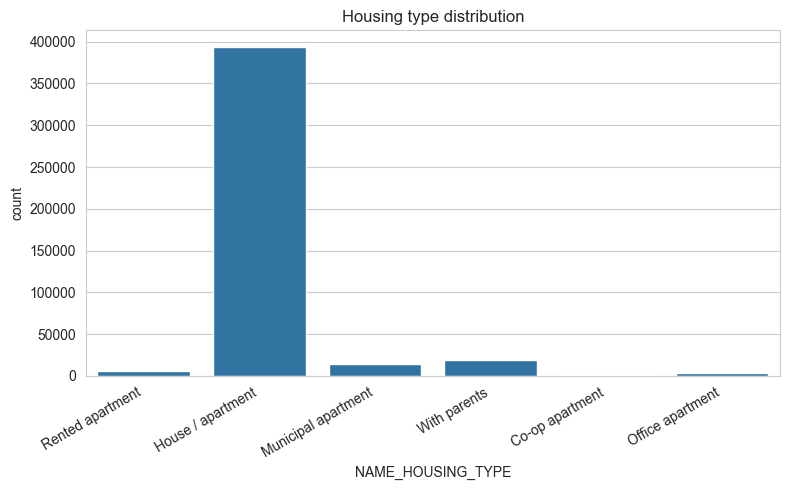

In [22]:
sns.countplot(x='NAME_HOUSING_TYPE', data=app_df)
plt.title('Housing type distribution')
plt.xticks(rotation=30, ha='right')  # Rotate labels
plt.tight_layout() 
plt.show()

### Findings
Housing: The overwhelming majority (393,831, ~90%) live in a house/apartment 
  they own or rent long-term, versus renting or living with parents.

### 1.8 occupation type

In [26]:
# Table
table = app_df['OCCUPATION_TYPE'].value_counts().reset_index()
table.columns = ['OCCUPATION_TYPE', 'Count']
table['Percentage'] = round((table['Count'] / table['Count'].sum()) * 100, 2)
table

,OCCUPATION_TYPE,Count,Percentage
0,Laborers,78240,25.71
1,Core staff,43007,14.13
2,Sales staff,41098,13.50
3,Managers,35487,11.66
4,Drivers,26090,8.57
5,High skill tech staff,17289,5.68
6,Accountants,15985,5.25
7,Medicine staff,13520,4.44
8,Cooking staff,8076,2.65
9,Security staff,7993,2.63


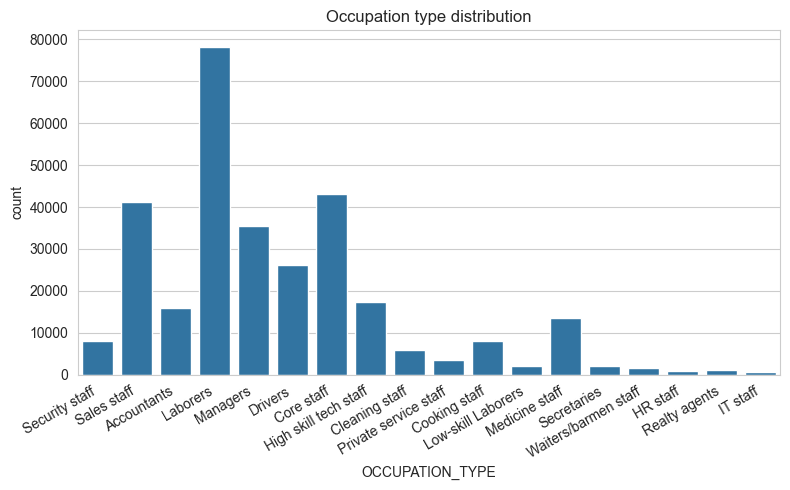

In [25]:
sns.countplot(x='OCCUPATION_TYPE', data=app_df)
plt.title('Occupation type distribution')
plt.xticks(rotation=30, ha='right')  # Rotate labels
plt.tight_layout() 
plt.show()

### Finding: 
Missing values are actually the single largest category in this 
column — 134,203 rows (30.6%) have no OCCUPATION_TYPE at all, more than any 
actual job title. Among known occupations, "Laborers" is the most common 
(78,240, 17.8%), followed by Core staff (43,007) and Sales staff (41,098). 
Several occupations are very rare — IT staff (604) and HR staff (774) barely 
register — which may cause sparsity issues after encoding in Epic 3/4.

### 1.9 DAYS_BIRTH

In [31]:
# Table
table = app_df['DAYS_BIRTH'].describe().to_frame().round(2)
table

,DAYS_BIRTH
count,438557.00
mean,-15997.90
std,4185.03
min,-25201.00
25%,-19483.00
50%,-15630.00
75%,-12514.00
max,-7489.00


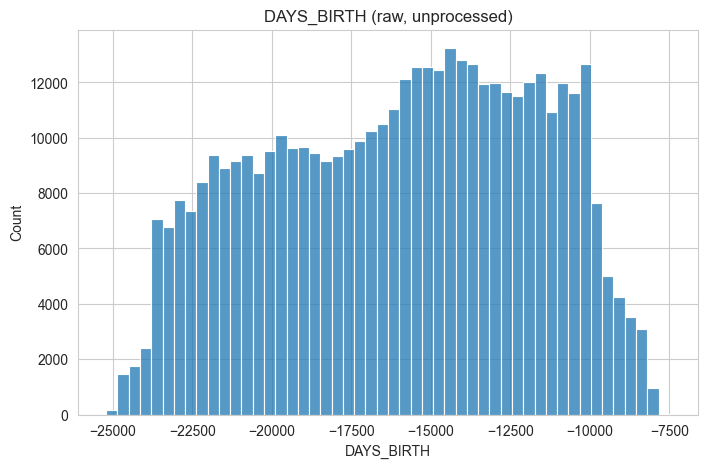

In [28]:
sns.histplot(app_df['DAYS_BIRTH'], bins=50)
plt.title('DAYS_BIRTH (raw, unprocessed)')
plt.show()

### 1.10  DAYS_EMPLOYED

In [30]:
# Table
table = app_df['DAYS_EMPLOYED'].describe().to_frame().round(2)
table

,DAYS_EMPLOYED
count,438557.00
mean,60563.68
std,138767.80
min,-17531.00
25%,-3103.00
50%,-1467.00
75%,-371.00
max,365243.00


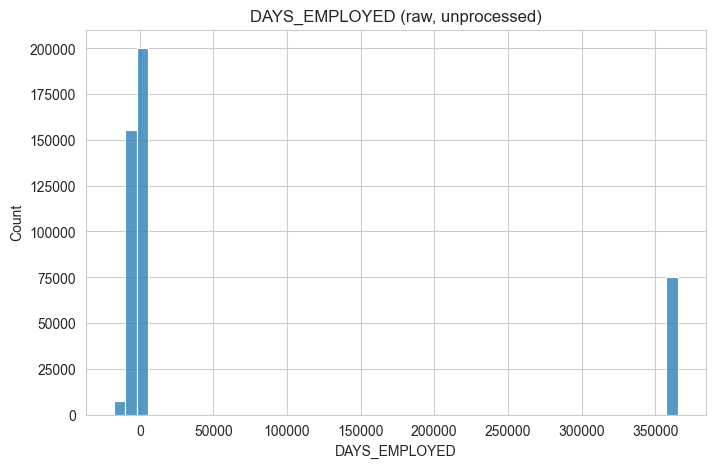

In [29]:
sns.histplot(app_df['DAYS_EMPLOYED'], bins=50)
plt.title('DAYS_EMPLOYED (raw, unprocessed)')
plt.show()

### Finding: 
DAYS_EMPLOYED contains a suspicious spike at exactly 365243 
(a positive value, when all real employment durations are negative day-counts). 
This affects 75,329 rows and corresponds to pensioners/unemployed applicants — 
this needs correcting in Epic 3 before the feature is usable.

### 1.11FLAG_OWN_CAR

In [32]:
# Table
table = app_df['FLAG_OWN_CAR'].value_counts().reset_index()
table.columns = ['FLAG_OWN_CAR', 'Count']
table['Percentage'] = round((table['Count'] / table['Count'].sum()) * 100, 2)
table

,FLAG_OWN_CAR,Count,Percentage
0,N,275459,62.81
1,Y,163098,37.19


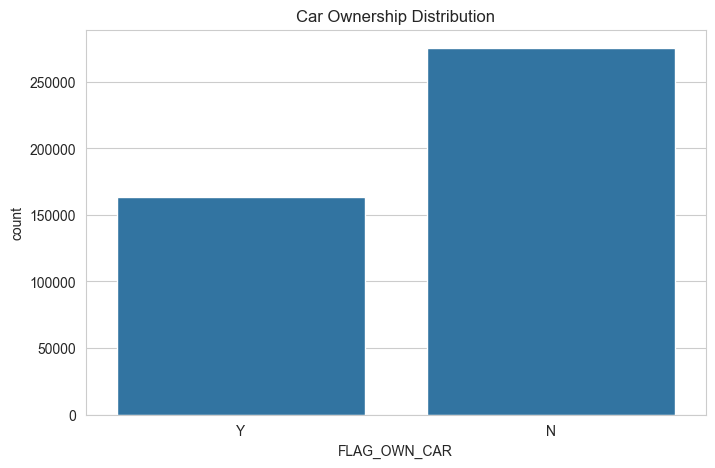

In [33]:
# Visualization
sns.countplot(x='FLAG_OWN_CAR', data=app_df)
plt.title('Car Ownership Distribution')
plt.show()

### Finding: 
163,098 applicants (37.2%) own a car, while 275,459 (62.8%) do not.

### 1.12 FLAG_OWN_REALTY

In [34]:
# Table
table = app_df['FLAG_OWN_REALTY'].value_counts().reset_index()
table.columns = ['FLAG_OWN_REALTY', 'Count']
table['Percentage'] = round((table['Count'] / table['Count'].sum()) * 100, 2)
table

,FLAG_OWN_REALTY,Count,Percentage
0,Y,304074,69.34
1,N,134483,30.66


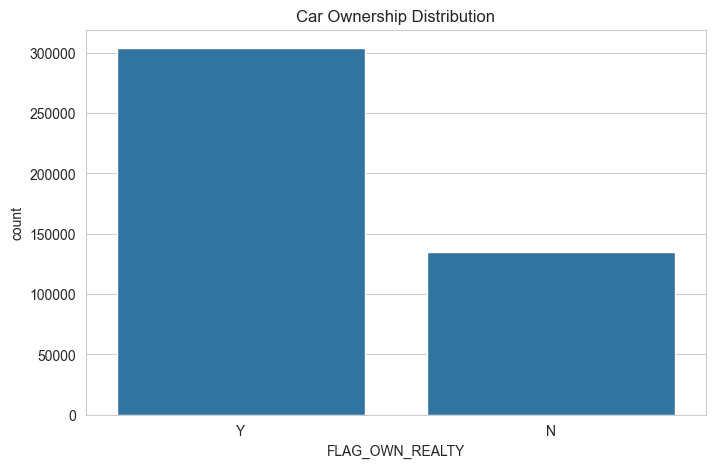

In [35]:
# Visualization
sns.countplot(x='FLAG_OWN_REALTY', data=app_df)
plt.title('Car Ownership Distribution')
plt.show()

### Finding: 
163,098 applicants (37.2%) own a car, while 275,459 (62.8%) do not.

### 1.13 Other binary columns

In [36]:
# Table
flag_cols = ['FLAG_MOBIL', 'FLAG_WORK_PHONE', 'FLAG_PHONE', 'FLAG_EMAIL']
table = app_df[flag_cols].apply(pd.Series.value_counts).fillna(0).astype(int)
table

,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL
0,0,348156,312353,391102
1,438557,90401,126204,47455


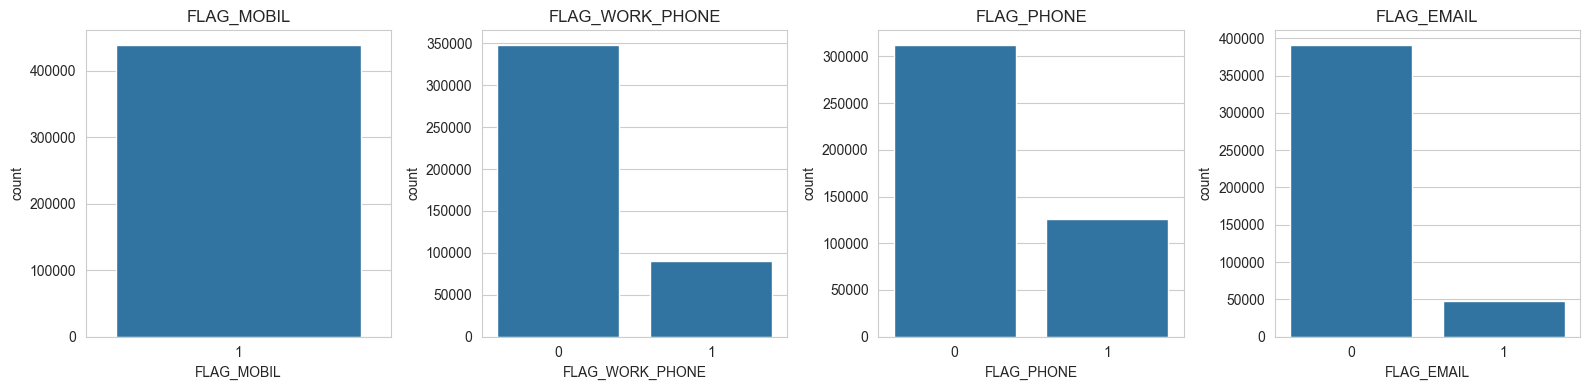

In [37]:
# Visualization
fig, axes = plt.subplots(1, 4, figsize=(16,4))
for i, col in enumerate(flag_cols):
    sns.countplot(x=col, data=app_df, ax=axes[i])
    axes[i].set_title(col)
plt.tight_layout()
plt.show()

### Finding: 
FLAG_MOBIL is constant — every single one of the 438,557 applicants 
has value 1, meaning this column carries zero information and is a strong 
candidate to drop entirely in Epic 3 (it can't help any model distinguish 
between applicants). Of the others, FLAG_WORK_PHONE is least common (90,401 
have one, 20.6%), FLAG_PHONE is more common (126,204, 28.8%), and FLAG_EMAIL is 
rarest of all (47,455, 10.8%).

## 2. Multivariate Analysis

### 2.1 Correlation heatmap

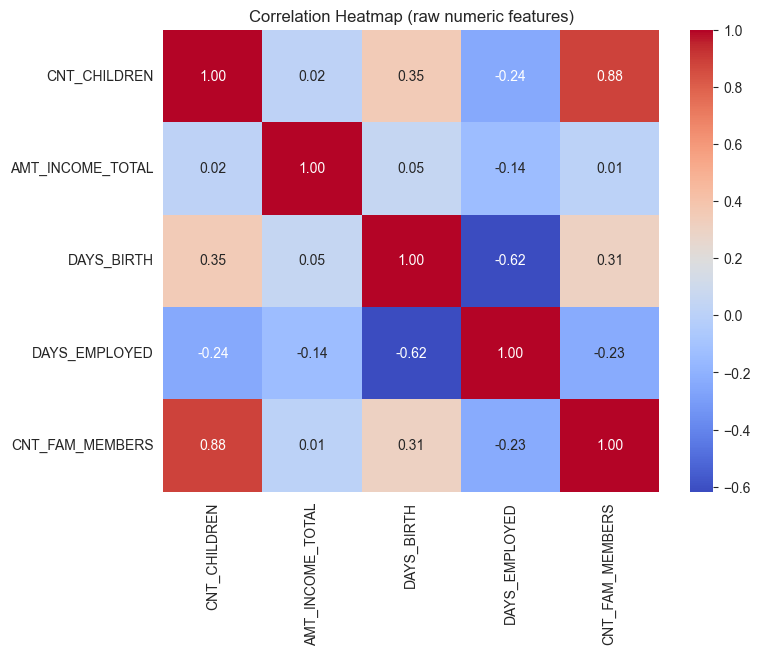

In [38]:
numeric_cols = ['CNT_CHILDREN', 'AMT_INCOME_TOTAL', 'DAYS_BIRTH', 'DAYS_EMPLOYED', 'CNT_FAM_MEMBERS']
plt.figure(figsize=(8,6))
sns.heatmap(app_df[numeric_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap (raw numeric features)')
plt.show()

### Finding: 
CNT_CHILDREN and CNT_FAM_MEMBERS are very strongly correlated (0.88), 
which makes sense since children count directly toward family size — this hints 
at redundant information that could cause multicollinearity in Epic 4 modeling. 
DAYS_BIRTH and DAYS_EMPLOYED show a moderate negative correlation (-0.62), 
meaning older applicants tend to have larger negative DAYS_EMPLOYED values 
(longer tenure).

### 2.2 Income vs income type

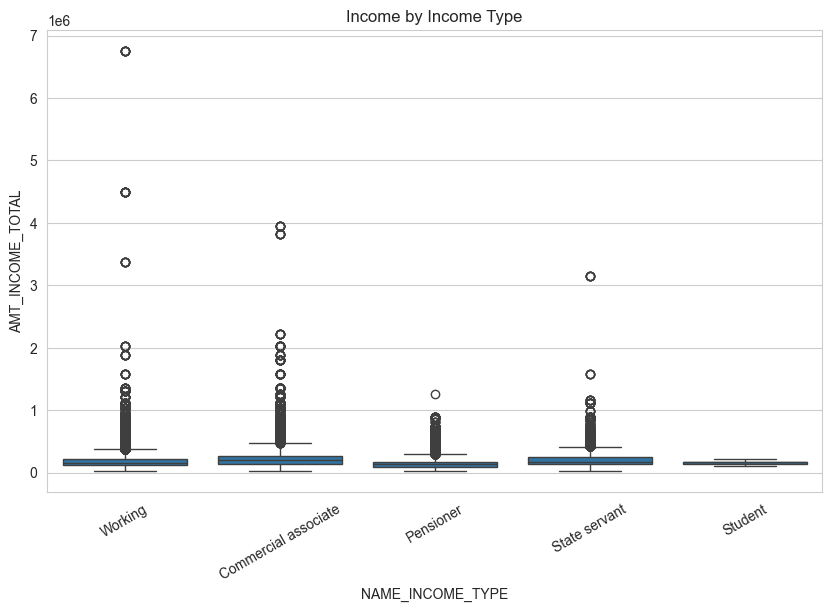

In [39]:
plt.figure(figsize=(10,6))
sns.boxplot(x='NAME_INCOME_TYPE', y='AMT_INCOME_TOTAL', data=app_df)
plt.xticks(rotation=30)
plt.title('Income by Income Type')
plt.show()

### Finding:
Commercial associates and State servants show noticeably higher 
median incomes than Working-class or Pensioner applicants, and also have 
more high-value outliers.

### 2.3 Gender vs owning a car / realty

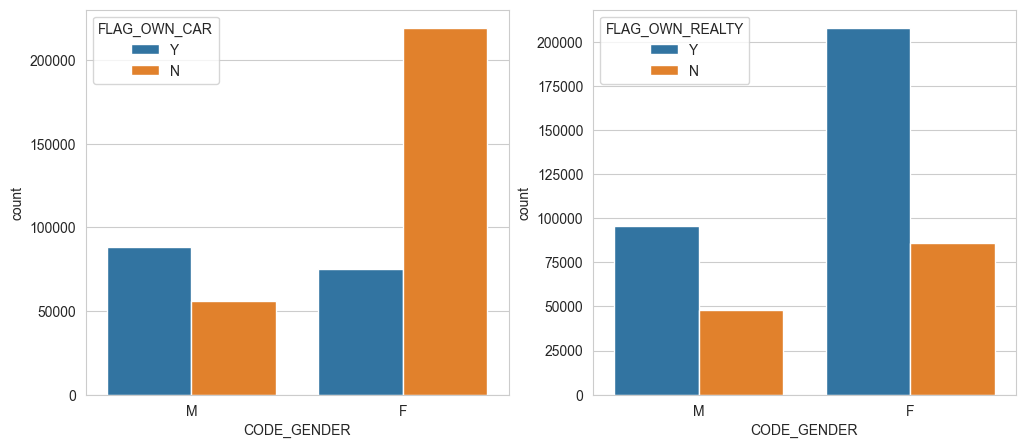

In [40]:
fig, axes = plt.subplots(1, 2, figsize=(12,5))
sns.countplot(x='CODE_GENDER', hue='FLAG_OWN_CAR', data=app_df, ax=axes[0])
sns.countplot(x='CODE_GENDER', hue='FLAG_OWN_REALTY', data=app_df, ax=axes[1])
plt.show()

### Finding: 
Male applicants own cars at a noticeably higher rate than female 
applicants proportionally, while realty ownership is high and fairly balanced 
across both genders.

### 2.4 Family status vs number of children

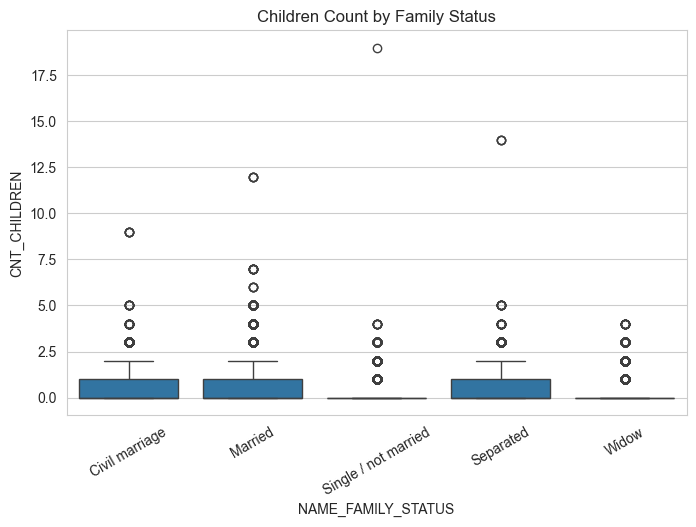

In [41]:
sns.boxplot(x='NAME_FAMILY_STATUS', y='CNT_CHILDREN', data=app_df)
plt.xticks(rotation=30)
plt.title('Children Count by Family Status')
plt.show()

### 3. Descriptive (Statistical) Analysis

In [42]:
app_df.describe()

,ID,CNT_CHILDREN,AMT_INCOME_TOTAL,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,CNT_FAM_MEMBERS
count,4.385570e+05,438557.000000,4.385570e+05,438557.000000,438557.000000,438557.0,438557.000000,438557.000000,438557.000000,438557.000000
mean,6.022176e+06,0.427390,1.875243e+05,-15997.904649,60563.675328,1.0,0.206133,0.287771,0.108207,2.194465
std,5.716370e+05,0.724882,1.100869e+05,4185.030007,138767.799647,0.0,0.404527,0.452724,0.310642,0.897207
min,5.008804e+06,0.000000,2.610000e+04,-25201.000000,-17531.000000,1.0,0.000000,0.000000,0.000000,1.000000
25%,5.609375e+06,0.000000,1.215000e+05,-19483.000000,-3103.000000,1.0,0.000000,0.000000,0.000000,2.000000
50%,6.047745e+06,0.000000,1.607805e+05,-15630.000000,-1467.000000,1.0,0.000000,0.000000,0.000000,2.000000
75%,6.456971e+06,1.000000,2.250000e+05,-12514.000000,-371.000000,1.0,0.000000,1.000000,0.000000,3.000000
max,7.999952e+06,19.000000,6.750000e+06,-7489.000000,365243.000000,1.0,1.000000,1.000000,1.000000,20.000000


### Finding:
- **ID** ranges from ~5.01M to ~8.00M — just a unique identifier, not a 
  meaningful feature for analysis or modeling; it'll be excluded from EDA 
  interpretation and later from model inputs.
- **CNT_CHILDREN**: mean (0.43) is well below the 75th percentile even reaching 
  1, and the max is 19 — a sharp outlier, since 75% of applicants have 0 or 1 
  child. This confirms the outlier concern already flagged in the univariate plot.
- **AMT_INCOME_TOTAL**: median (160,780) is noticeably lower than the mean 
  (187,524), confirming the right-skew seen earlier. The gap between the 75th 
  percentile (225,000) and the max (6,750,000) is enormous — a small number of 
  very high earners are pulling the average up.
- **DAYS_BIRTH**: all values are negative as expected (days counted backward 
  from the data snapshot date), ranging from -25,201 to -7,489, i.e. roughly 
  20 to 69 years old once converted — a reasonable working-age range with no 
  obvious data errors.
- **DAYS_EMPLOYED**: this is the most problematic column. The 25th, 50th, and 
  75th percentiles are all negative (as expected for actual employment 
  duration), but the max is 365,243 — a physically impossible value (over 
  1,000 years) — and it single-handedly drags the mean to a nonsensical 
  positive 60,564, even though most of the distribution is negative. This 
  confirms the pensioner/unemployed sentinel-value issue found in the 
  univariate histogram and makes clear the mean here is meaningless until 
  Epic 3 fixes it.
- **FLAG_MOBIL**: std is 0.0 and every statistic is 1 — mathematically confirms 
  this column is constant across all 438,557 rows, reinforcing the case to 
  drop it.
- **FLAG_WORK_PHONE / FLAG_PHONE / FLAG_EMAIL**: means of 0.21, 0.29, and 0.11 
  respectively directly reflect the proportions found in the univariate 
  section (20.6%, 28.8%, 10.8% ownership).
- **CNT_FAM_MEMBERS**: median of 2 with a max of 20 mirrors the CNT_CHILDREN 
  outlier pattern, consistent with the strong 0.88 correlation already found 
  between the two in the multivariate analysis.

In [43]:
app_df.isnull().sum()

ID                          0
CODE_GENDER                 0
FLAG_OWN_CAR                0
FLAG_OWN_REALTY             0
CNT_CHILDREN                0
AMT_INCOME_TOTAL            0
NAME_INCOME_TYPE            0
NAME_EDUCATION_TYPE         0
NAME_FAMILY_STATUS          0
NAME_HOUSING_TYPE           0
DAYS_BIRTH                  0
DAYS_EMPLOYED               0
FLAG_MOBIL                  0
FLAG_WORK_PHONE             0
FLAG_PHONE                  0
FLAG_EMAIL                  0
OCCUPATION_TYPE        134203
CNT_FAM_MEMBERS             0
dtype: int64

### Finding: 
Only one column has missing data: OCCUPATION_TYPE, with 134,203 
missing values out of 438,557 rows (~30.6%). No other column in 
application_record.csv has nulls. This will need to be addressed in Epic 3.

In [45]:

app_df['ID'].duplicated().sum()

np.int64(47)

### Finding: 
There are no fully duplicated rows, but 47 duplicate ID values exist, 
meaning the same applicant appears more than once — these will be de-duplicated 
in Epic 3.

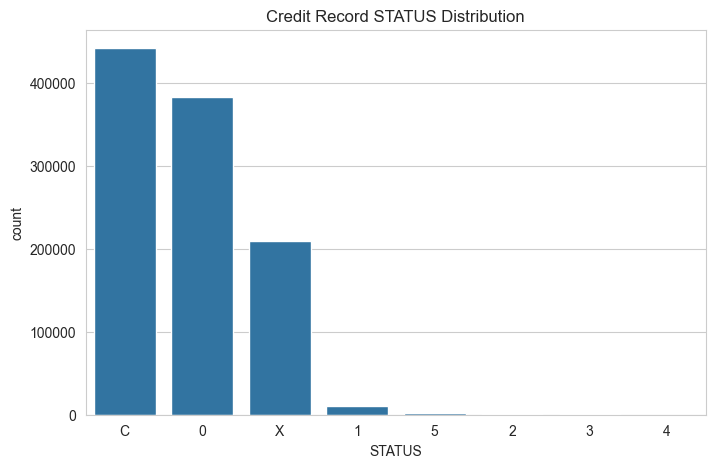

In [47]:
sns.countplot(x='STATUS', data=cred_df, order=cred_df['STATUS'].value_counts().index)
plt.title('Credit Record STATUS Distribution')
plt.show()

### Finding: 
STATUS 'C' (paid off) and '0' (on-time, no overdue) dominate the 
credit record (442,031 and 383,120 rows respectively), while severe delinquency 
statuses (2-5, meaning 60+ days overdue) are rare — fewer than 3,200 rows combined. 
This shows a strong class imbalance that will carry over into the target label 
built in Epic 3, and will need to be accounted for during model evaluation in Epic 4.